In [13]:
from langchain_chroma import Chroma
from pdf_chunk import text_spliter
from models import get_model , get_embeddings
from langchain_community.tools import DuckDuckGoSearchRun
from typing import List, Literal
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [2]:
model = get_model()
embedding_model = get_embeddings()
chunks = text_spliter

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 663.60it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
vectorstore=Chroma.from_documents(chunks ,embedding_model )
retriever = vectorstore.as_retriever(search_type="mmr",search_kwargs={"k": 10, "include_metadata": True})

In [35]:
web_search = DuckDuckGoSearchRun()

In [36]:
class CRAGState(TypedDict):
    question        : str              # original user query
    documents       : List[Document]   # retrieved / web docs
    generation      : str              # final LLM answer
    web_search_needed: str             # "yes" | "no"

In [37]:
grader_prompt = ChatPromptTemplate.from_template("""
You are a relevance grader. Does the document contain information
relevant to answer the question?
Answer with ONLY "yes" or "no".

Question: {question}
Document: {document}
Score:
""")

In [38]:
grader_chain = grader_prompt | model| StrOutputParser()

In [39]:
rewriter_prompt = ChatPromptTemplate.from_template("""
Rewrite this question into a better web search query.
Output only the rewritten query, nothing else.

Question: {question}
Rewritten query:
""")


In [40]:
rewriter_chain = rewriter_prompt | model | StrOutputParser()

In [41]:
answer_prompt = ChatPromptTemplate.from_template("""
Answer the question using only the context below.
If the answer is not in the context, say "I don't know".

Context: {context}
Question: {question}
Answer:
""")

In [42]:
answer_chain = answer_prompt | model | StrOutputParser()

In [43]:
def retrieve(state: CRAGState) -> dict:
    """Node 1 — retrieve top-k docs from Chroma."""
    print("--- NODE: retrieve ---")
    docs = retriever.invoke(state["question"])
    return {"documents": docs}

In [44]:
def grade_documents(state: CRAGState) -> dict:
    """
    Node 2 — grade each doc.
    Sets web_search_needed = "yes" if any doc is irrelevant.
    """
    print("--- NODE: grade_documents ---")
    question  = state["question"]
    docs      = state["documents"]

    relevant_docs     = []
    web_search_needed = "no"

    for doc in docs:
        score = grader_chain.invoke({
            "question": question,
            "document": doc.page_content
        }).strip().lower()

        if "yes" in score:
            print(f"  RELEVANT   : {doc.page_content[:60]}...")
            relevant_docs.append(doc)
        else:
            print(f"  IRRELEVANT : {doc.page_content[:60]}...")
            web_search_needed = "yes"   # at least one bad doc → trigger web

    return {
        "documents"        : relevant_docs,
        "web_search_needed": web_search_needed
    }

In [45]:
def rewrite_query(state: CRAGState) -> dict:
    """Node 3 — rewrite query for better web search."""
    print("--- NODE: rewrite_query ---")
    rewritten = rewriter_chain.invoke({
        "question": state["question"]
    }).strip()
    print(f"  Rewritten: {rewritten}")
    # update question so web_search node uses the better query
    return {"question": rewritten}

In [46]:
def web_search_node(state: CRAGState) -> dict:
    """Node 4 — search the web, append results to documents."""
    print("--- NODE: web_search ---")
    results = web_search.invoke(state["question"])

    web_doc = Document(
        page_content=results,
        metadata={"source": "duckduckgo", "type": "web"}
    )

    # Append web result to whatever relevant docs survived grading
    updated_docs = state["documents"] + [web_doc]
    return {"documents": updated_docs}

In [47]:
def generate(state: CRAGState) -> dict:
    """Node 5 — generate final answer from documents."""
    print("--- NODE: generate ---")
    context = "\n\n".join([d.page_content for d in state["documents"]])
    answer  = answer_chain.invoke({
        "question": state["question"],
        "context" : context
    })
    return {"generation": answer}

In [48]:
def decide_after_grading(state: CRAGState) -> Literal["rewrite_query", "generate"]:
    """
    Conditional edge after grade_documents.
    If any doc was irrelevant → rewrite query → web search → generate
    If all docs relevant     → go directly to generate
    """
    if state["web_search_needed"] == "yes":
        print("--- EDGE: irrelevant docs found → rewrite + web search ---")
        return "rewrite_query"
    else:
        print("--- EDGE: all docs relevant → generate directly ---")
        return "generate"

In [49]:
graph_builder = StateGraph(CRAGState)

In [50]:
graph_builder.add_node("retrieve",        retrieve)
graph_builder.add_node("grade_documents", grade_documents)
graph_builder.add_node("rewrite_query",   rewrite_query)
graph_builder.add_node("web_search",      web_search_node)
graph_builder.add_node("generate",        generate)

In [51]:
graph_builder.add_edge(START,            "retrieve")
graph_builder.add_edge("retrieve",       "grade_documents")
graph_builder.add_edge("rewrite_query",  "web_search")
graph_builder.add_edge("web_search",     "generate")
graph_builder.add_edge("generate",       END)

In [52]:
graph_builder.add_conditional_edges(
    "grade_documents",       # from this node
    decide_after_grading,    # call this function to decide
    {
        "rewrite_query": "rewrite_query",  # if irrelevant → rewrite
        "generate"     : "generate",       # if relevant   → generate
    }
)

In [53]:
crag_graph = graph_builder.compile()

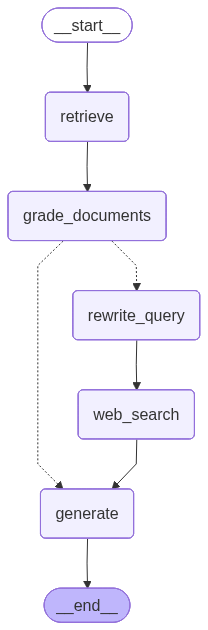

In [54]:
crag_graph

In [55]:
def run_crag(question: str) -> str:
    """Invoke the CRAG graph and return the final answer."""
    print(f"\n{'═'*60}")
    print(f"QUESTION: {question}")
    print(f"{'═'*60}")

    result = crag_graph.invoke({"question": question})

    print(f"\nFINAL ANSWER:\n{result['generation']}")
    return result["generation"]

In [56]:
run_crag("What is Rohanta's current university?")


════════════════════════════════════════════════════════════
QUESTION: What is Rohanta's current university?
════════════════════════════════════════════════════════════
--- NODE: retrieve ---
--- NODE: grade_documents ---
  IRRELEVANT : Before transitioning fully into industry, Rohanta taught und...
  IRRELEVANT : Rohanta Bhamare is an AI Engineer with 5+ years of experienc...
  IRRELEVANT : Role: Assistant Professor
Institution: Guru Gobind Singh Fou...
  IRRELEVANT : IDENTITY AND CONTACT

Full Name: Rohanta Dinkar Bhamare
Titl...
  IRRELEVANT : Rohanta is looking for full-time roles as an ML Engineer, AI...
  IRRELEVANT : PERSONAL RAG CHATBOT â€” TECHNICAL ARCHITECTURE

This chatbo...
  IRRELEVANT : Degree: Master of Engineering (ME)
Institution: Savitribai P...
  IRRELEVANT : He is currently open to ML Engineer, AI Engineer, and NLP En...
  IRRELEVANT : Beyond LLM systems, Rohanta has a strong foundation in class...
  IRRELEVANT : Secondary Education:
SSC (Secondary School Certifi

"I don't know."

In [57]:
run_crag("What is the latest version of LangGraph released in 2025?")


════════════════════════════════════════════════════════════
QUESTION: What is the latest version of LangGraph released in 2025?
════════════════════════════════════════════════════════════
--- NODE: retrieve ---
--- NODE: grade_documents ---
  IRRELEVANT : Degree: Master of Engineering (ME)
Institution: Savitribai P...
  IRRELEVANT : Programming Languages: Python (primary), SQL, Bash
Deep Lear...
  IRRELEVANT : Rohanta has deep expertise in Retrieval-Augmented Generation...
  IRRELEVANT : EDUCATION

Degree: MSc in Artificial Intelligence
Institutio...
  IRRELEVANT : He understands the tradeoffs between chunk size (smaller chu...
  IRRELEVANT : Beyond LLM systems, Rohanta has a strong foundation in class...
  IRRELEVANT : LLM: Groq API with Llama3 model (llama-3.1-8b-instant)
Embed...
  IRRELEVANT : PERSONAL RAG CHATBOT â€” TECHNICAL ARCHITECTURE

This chatbo...
  IRRELEVANT : NLP: spaCy, NLTK, TF-IDF, Word2Vec, BERT, text classificatio...
  IRRELEVANT : DEPLOYED PROJECTS

Project: Pe

'LangGraph 1.1.2.'

In [58]:
run_crag("What AI frameworks is Rohanta using and which are newest?")


════════════════════════════════════════════════════════════
QUESTION: What AI frameworks is Rohanta using and which are newest?
════════════════════════════════════════════════════════════
--- NODE: retrieve ---
--- NODE: grade_documents ---
  IRRELEVANT : reasoning. Rohanta actively experiments with state managemen...
  IRRELEVANT : Rohanta Bhamare is an AI Engineer with 5+ years of experienc...
  RELEVANT   : Rohanta is currently working as a self-employed AI/ML Consul...
  IRRELEVANT : PERSONAL RAG CHATBOT â€” TECHNICAL ARCHITECTURE

This chatbo...
  RELEVANT   : Rohanta is looking for full-time roles as an ML Engineer, AI...
  IRRELEVANT : Rohanta believes AI systems must be reliable, observable, te...
  IRRELEVANT : Before transitioning fully into industry, Rohanta taught und...
  IRRELEVANT : Unlike traditional machine learning engineers who focus only...
  IRRELEVANT : DEPLOYED PROJECTS

Project: Personal RAG Chatbot
URL: Availa...
  IRRELEVANT : and sequence modeling. He has 

'CrewAI, LangChain, and Hugging Face are mentioned as AI frameworks.'